In [31]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from sklearn.pipeline import Pipeline
import joblib
import os
from sklearn.preprocessing import LabelEncoder

ignorewarnings = True

In [2]:
df = pd.read_excel('../data_final_semua.xlsx')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   plant         1210 non-null   int64         
 1   day           1210 non-null   int64         
 2   leaf_count    1210 non-null   int64         
 3   plant_height  1210 non-null   float64       
 4   leaf_length   1210 non-null   float64       
 5   leaf_width    1210 non-null   float64       
 6   date          1210 non-null   datetime64[ns]
 7   ph            1210 non-null   float64       
 8   ppm           1210 non-null   float64       
 9   water_temp    1210 non-null   float64       
 10  air_temp      1210 non-null   float64       
 11  humidity      1210 non-null   float64       
 12  plant_type    1210 non-null   object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 123.0+ KB


In [5]:
def categorize_ppm(value):
    if value < 950:
        return "Very Low"
    elif value < 1050:
        return "Low"
    elif value < 1150:
        return "Medium"
    else:
        return "High"

df['ppm_category'] = df['ppm'].apply(categorize_ppm)

In [6]:
print(df[['ppm', 'ppm_category']].head(10))

          ppm ppm_category
0  888.677043     Very Low
1  888.677043     Very Low
2  888.677043     Very Low
3  888.677043     Very Low
4  888.677043     Very Low
5  888.677043     Very Low
6  888.677043     Very Low
7  888.677043     Very Low
8  888.677043     Very Low
9  888.677043     Very Low


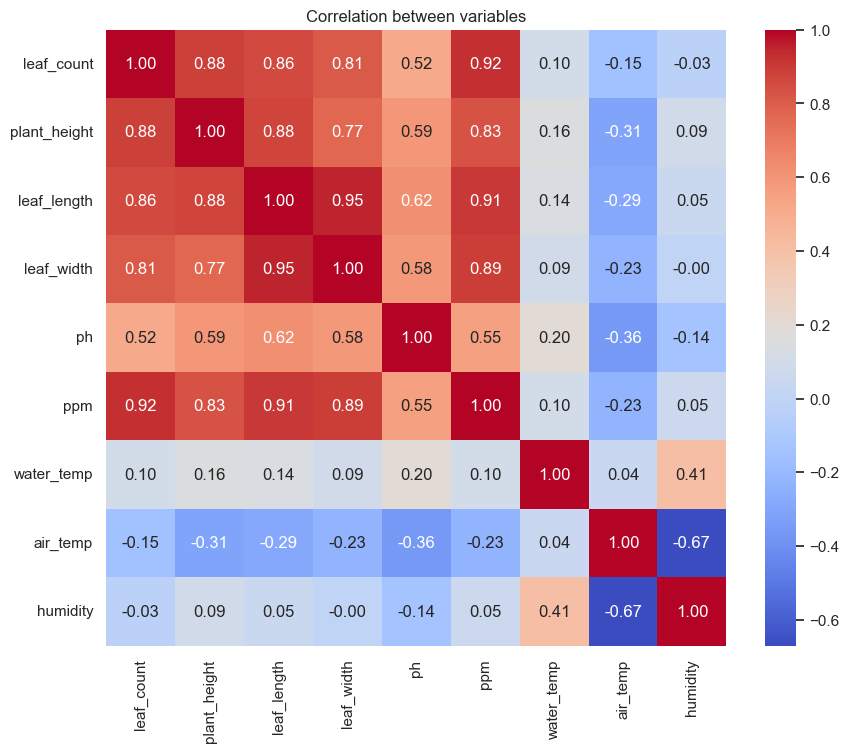

In [24]:
corr = df[['leaf_count','plant_height','leaf_length','leaf_width','ph','ppm','water_temp','air_temp','humidity']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between variables')
plt.show()

In [32]:
le = LabelEncoder()
df['plant_type'] = le.fit_transform(df['plant_type'])

In [33]:
print("\nMapping kategori -> angka:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} -> {i}")


Mapping kategori -> angka:
Lettuce -> 0
Pak Choi -> 1


### Semua sensor + tanaman

In [43]:
X = df[['ph', 'water_temp', 'air_temp', 'humidity',
        'leaf_count', 'plant_height', 'leaf_length', 'leaf_width']]

y = df['ppm_category']

In [44]:
y_encoded = le.fit_transform(y)

In [45]:
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping label:", label_map)

Mapping label: {'High': 0, 'Low': 1, 'Medium': 2, 'Very Low': 3}


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [49]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        89
         Low       1.00      1.00      1.00       101
      Medium       1.00      1.00      1.00        72
    Very Low       1.00      1.00      1.00       101

    accuracy                           1.00       363
   macro avg       1.00      1.00      1.00       363
weighted avg       1.00      1.00      1.00       363



        Feature  Importance
0            ph    0.207454
4    leaf_count    0.177140
7    leaf_width    0.162330
2      air_temp    0.109542
6   leaf_length    0.097583
5  plant_height    0.083918
3      humidity    0.083777
1    water_temp    0.078257


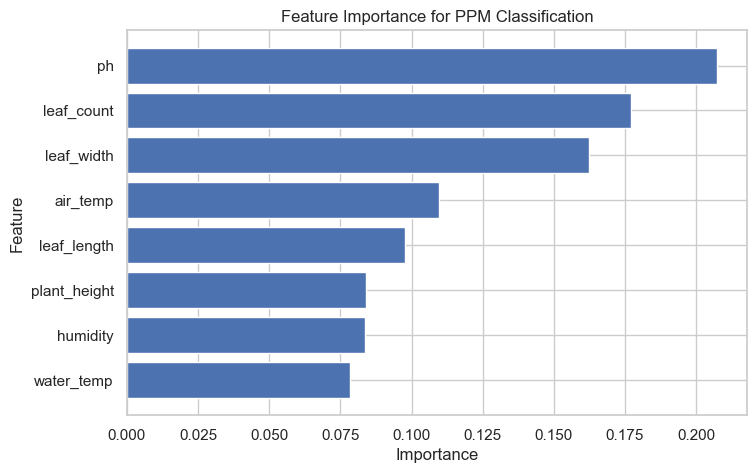

In [50]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Tampilkan 10 fitur paling penting
print(feature_importance)

# Visualisasi
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PPM Classification')
plt.gca().invert_yaxis()
plt.show()

In [51]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"CV f1_macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV f1_macro: 1.0000 ± 0.0000


In [53]:
pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)
print(classification_report(y_test, y_pred_pipe, target_names=le.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        89
         Low       1.00      1.00      1.00       101
      Medium       1.00      1.00      1.00        72
    Very Low       1.00      1.00      1.00       101

    accuracy                           1.00       363
   macro avg       1.00      1.00      1.00       363
weighted avg       1.00      1.00      1.00       363



In [54]:
out_dir = 'model_all_data'
os.makedirs(out_dir, exist_ok=True)

In [55]:
joblib.dump(pipeline, os.path.join(out_dir, 'all_data_rf_pipeline.joblib'))
joblib.dump(pipeline.named_steps['scaler'], os.path.join(out_dir, 'all_data_scaler.joblib'))
joblib.dump(le, os.path.join(out_dir, 'all_data_label_encoder.joblib'))
joblib.dump(list(X.columns), os.path.join(out_dir, 'all_data_feature_names.joblib'))
metadata = {'cv_scores': cv_scores.tolist(), 'random_state': 42}
joblib.dump(metadata, os.path.join(out_dir, 'all_data_metadata.joblib'))

['model_all_data\\all_data_metadata.joblib']

### Hanya Sensor

In [56]:
X2 = df[['ph', 'water_temp', 'air_temp', 'humidity']]

y2 = df['ppm_category']

In [57]:
le2 = LabelEncoder()
y2_encoded = le2.fit_transform(y2)

In [58]:
label_map2 = dict(zip(le2.classes_, le2.transform(le2.classes_)))
print("Mapping label:", label_map2)

Mapping label: {'High': 0, 'Low': 1, 'Medium': 2, 'Very Low': 3}


In [59]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2_encoded, test_size=0.3, random_state=42
)

In [60]:
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

In [61]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train2_scaled, y_train2)

RandomForestClassifier(random_state=42)

In [62]:
y_pred2 = model2.predict(X_test2_scaled)
print(classification_report(y_test2, y_pred2, target_names=le2.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        89
         Low       1.00      1.00      1.00       101
      Medium       1.00      1.00      1.00        72
    Very Low       1.00      1.00      1.00       101

    accuracy                           1.00       363
   macro avg       1.00      1.00      1.00       363
weighted avg       1.00      1.00      1.00       363



      Feature  Importance
0          ph    0.359918
2    air_temp    0.331984
1  water_temp    0.175938
3    humidity    0.132159


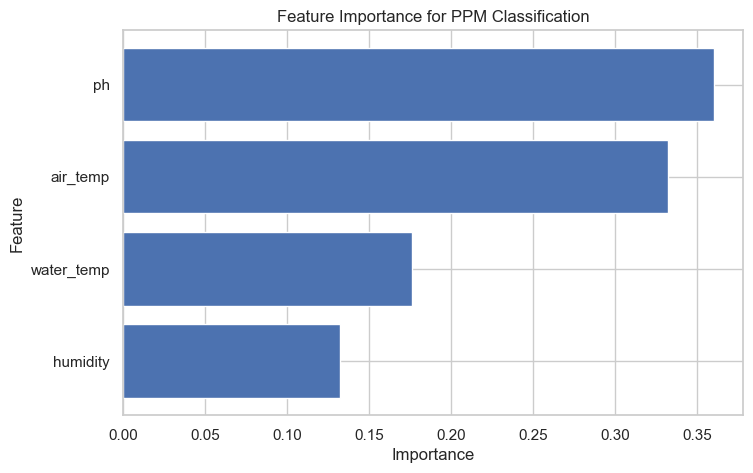

In [63]:
importance2 = model2.feature_importances_
feature_importance2 = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': importance2
}).sort_values(by='Importance', ascending=False)

# Tampilkan 10 fitur paling penting
print(feature_importance2)

# Visualisasi
plt.figure(figsize=(8,5))
plt.barh(feature_importance2['Feature'], feature_importance2['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PPM Classification')
plt.gca().invert_yaxis()
plt.show()

In [64]:
pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [65]:
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores2 = cross_val_score(pipeline2, X2, y2, cv=cv2, scoring='f1_macro', n_jobs=-1)
print(f"CV f1_macro: {cv_scores2.mean():.4f} ± {cv_scores2.std():.4f}")

CV f1_macro: 1.0000 ± 0.0000


In [66]:
pipeline2.fit(X_train2, y_train2)
y_pred_pipe2 = pipeline2.predict(X_test2)
print(classification_report(y_test2, y_pred_pipe2, target_names=le2.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        89
         Low       1.00      1.00      1.00       101
      Medium       1.00      1.00      1.00        72
    Very Low       1.00      1.00      1.00       101

    accuracy                           1.00       363
   macro avg       1.00      1.00      1.00       363
weighted avg       1.00      1.00      1.00       363



In [67]:
out_dir2 = 'model_all_sensor_data'
os.makedirs(out_dir2, exist_ok=True)

In [68]:
joblib.dump(pipeline2, os.path.join(out_dir2, 'all_data_rf_pipeline.joblib'))
joblib.dump(pipeline2.named_steps['scaler'], os.path.join(out_dir2, 'all_data_scaler.joblib'))
joblib.dump(le2, os.path.join(out_dir2, 'all_data_label_encoder.joblib'))
joblib.dump(list(X2.columns), os.path.join(out_dir2, 'all_data_feature_names.joblib'))
metadata = {'cv_scores': cv_scores2.tolist(), 'random_state': 42}
joblib.dump(metadata, os.path.join(out_dir2, 'all_data_metadata.joblib'))

['model_all_sensor_data\\all_data_metadata.joblib']